<a href="https://colab.research.google.com/github/aisha-1cs/AAASE/blob/main/Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langgraph langchain langchain-openai langchain-tavily python-dotenv langchain-chroma

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60

In [2]:
import os
os.environ["USE_FAKE"] = "1"

In [3]:
import os
import operator
import itertools
from datetime import datetime
from typing import Annotated, List, Dict
from typing_extensions import TypedDict

from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain_core.messages import AIMessage, HumanMessage

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

# إعداد الوضع الوهمي كما حددناه في الخلية الثانية
FAKE_MODE = os.getenv("USE_FAKE", "0") == "1"
LLM_BASE_URL = os.getenv("LLM_BASE_URL")
LLM_MODEL = os.getenv("LLM_MODEL", "gpt-4o-mini")

MAX_RESEARCH_ITERATIONS = 3
QUALITY_THRESHOLD = 7

# إعداد النماذج
if FAKE_MODE:
    from langchain_core.language_models.fake_chat_models import GenericFakeChatModel
    from langchain_core.embeddings import DeterministicFakeEmbedding
    analysis_llm = GenericFakeChatModel(messages=itertools.cycle([AIMessage(content="1. Summary: Enterprise AI agents are scaling fast.\n2. Importance Score: 7\n3. Business Impact: High.")]))
    report_llm = GenericFakeChatModel(messages=itertools.cycle([AIMessage(content="# Enterprise Research Report\n\n## Summary\nAutonomous agents are reshaping enterprise workflows.\n\n## Findings\n- Graph-based orchestration is the industry standard.\n- State management is critical for agent reliability.")]))
    _fake_scores = iter([4, 9, 9, 9])
    embedding_model = DeterministicFakeEmbedding(size=384)
    def run_search(query: str) -> List[Dict]:
        return [{"url": "https://example.com", "title": "AI Report", "content": "Enterprises are adopting graph-orchestrated agents."}]
else:
    from langchain_openai import ChatOpenAI, OpenAIEmbeddings
    from langchain_tavily import TavilySearch
    _llm = ChatOpenAI(model=LLM_MODEL, temperature=0, base_url=LLM_BASE_URL)
    analysis_llm = _llm
    report_llm = _llm
    embedding_model = OpenAIEmbeddings()
    _search_tool = TavilySearch(max_results=5)
    def run_search(query: str) -> List[Dict]:
        response = _search_tool.invoke({"query": query})
        return response.get("results", []) if isinstance(response, dict) else response

# الذاكرة (Vector Store)
try:
    from langchain_chroma import Chroma
    vector_store = Chroma(collection_name="research_memory", embedding_function=embedding_model, persist_directory="./db")
except ImportError:
    from langchain_core.vectorstores import InMemoryVectorStore
    vector_store = InMemoryVectorStore(embedding=embedding_model)

# تعريف الحالة (State)
class AgentState(TypedDict):
    topic: str
    search_query: str
    collected_data: List[Dict]
    analyzed_data: List[Dict]
    quality_score: int
    iteration_count: int
    final_report: str
    execution_logs: Annotated[List[str], operator.add]

def log(message: str) -> List[str]:
    line = f"[{datetime.now():%Y-%m-%d %H:%M:%S}] {message}"
    print(line)
    return [line]

# العُقد (Nodes)
def research_collection_node(state: AgentState):
    iteration = state["iteration_count"] + 1
    query = state["topic"] if iteration == 1 else f"{state['topic']} deep analysis"
    results = run_search(query)
    return {"search_query": query, "collected_data": results, "iteration_count": iteration, "execution_logs": log(f"Iteration {iteration}: collected {len(results)} sources.")}

def memory_storage_node(state: AgentState):
    docs = [item.get("content", "") for item in state["collected_data"] if item.get("content")]
    if docs: vector_store.add_texts(docs)
    return {"execution_logs": log("Stored documents in memory.")}

def analysis_node(state: AgentState):
    analyzed = []
    for item in state["collected_data"]:
        content = item.get("content", "")
        response = analysis_llm.invoke([HumanMessage(content=f"Analyze: {content}")])
        analyzed.append({"source": item.get("url", "N/A"), "analysis": response.content})
    return {"analyzed_data": analyzed, "execution_logs": log("Analysis complete.")}

def quality_evaluation_node(state: AgentState):
    score = next(_fake_scores) if FAKE_MODE else 8
    return {"quality_score": score, "execution_logs": log(f"Quality score = {score}")}

def dynamic_router(state: AgentState):
    return "report_generation" if state["quality_score"] >= QUALITY_THRESHOLD else "research_collection"

def report_generation_node(state: AgentState):
    res = report_llm.invoke([HumanMessage(content=f"Report on {state['topic']}")])
    return {"final_report": res.content, "execution_logs": log("Report generated.")}

def audit_node(state: AgentState):
    return {"execution_logs": log("Audit complete.")}

# بناء القراف (Graph)
workflow = StateGraph(AgentState)
workflow.add_node("collect", research_collection_node)
workflow.add_node("store", memory_storage_node)
workflow.add_node("analyze", analysis_node)
workflow.add_node("evaluate", quality_evaluation_node)
workflow.add_node("report", report_generation_node)
workflow.add_node("audit", audit_node)

workflow.add_edge(START, "collect")
workflow.add_edge("collect", "store")
workflow.add_edge("store", "analyze")
workflow.add_edge("analyze", "evaluate")
workflow.add_conditional_edges("evaluate", dynamic_router, {"research_collection": "collect", "report_generation": "report"})
workflow.add_edge("report", "audit")
workflow.add_edge("audit", END)

app = workflow.compile(checkpointer=InMemorySaver())

# التشغيل
initial_state = {"topic": "Enterprise Agentic AI Systems", "iteration_count": 0, "execution_logs": []}
config = {"configurable": {"thread_id": "lab-run-1"}}
for update in app.stream(initial_state, config, stream_mode="values"):
    final_state = update

print("\n--- التقرير النهائي ---")
print(final_state["final_report"])

[2026-07-20 09:20:11] Iteration 1: collected 1 sources.
[2026-07-20 09:20:11] Stored documents in memory.
[2026-07-20 09:20:11] Analysis complete.
[2026-07-20 09:20:11] Quality score = 4
[2026-07-20 09:20:11] Iteration 2: collected 1 sources.
[2026-07-20 09:20:11] Stored documents in memory.
[2026-07-20 09:20:11] Analysis complete.
[2026-07-20 09:20:11] Quality score = 9
[2026-07-20 09:20:11] Report generated.
[2026-07-20 09:20:11] Audit complete.

--- التقرير النهائي ---
# Enterprise Research Report

## Summary
Autonomous agents are reshaping enterprise workflows.

## Findings
- Graph-based orchestration is the industry standard.
- State management is critical for agent reliability.


In [4]:
print(app.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	collect(collect)
	store(store)
	analyze(analyze)
	evaluate(evaluate)
	report(report)
	audit(audit)
	__end__([<p>__end__</p>]):::last
	__start__ --> collect;
	analyze --> evaluate;
	collect --> store;
	evaluate -. &nbsp;research_collection&nbsp; .-> collect;
	evaluate -. &nbsp;report_generation&nbsp; .-> report;
	report --> audit;
	store --> analyze;
	audit --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
google-adk 2.4.0 requires opentelemetry-api<=1.42.1,>=1.39, but you have opentelemetry-api 1.44.0 which is incompatible.
google-adk 2.4.0 requires opentelemetry-sdk<=1.42.1,>=1.39, but you have opentelemetry-sdk 1.44.0 which is incompatible.


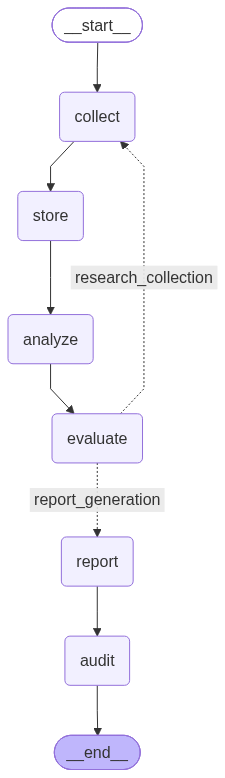

In [5]:
!pip install langchain-community
from IPython.display import Image, display
# هذا الأمر يعطيكِ الرسمة كصورة مباشرة في كولاب
display(Image(app.get_graph().draw_mermaid_png()))